In [2]:
import yfinance as yf
import pandas as pd

In [3]:


tickers = ['TSLA', 'BND', 'SPY']
start = "2015-07-01"
end = "2025-07-31"

data = {}
for ticker in tickers:
    data[ticker] = yf.download(ticker, start=start, end=end)

# Optional: save to CSV for quick reload later
for ticker in tickers:
    data[ticker].to_csv(f"{ticker}.csv")


C:\Users\nebiy\AppData\Local\Temp\ipykernel_21452\2444444092.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data[ticker] = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
C:\Users\nebiy\AppData\Local\Temp\ipykernel_21452\2444444092.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data[ticker] = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
C:\Users\nebiy\AppData\Local\Temp\ipykernel_21452\2444444092.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data[ticker] = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


In [4]:
for ticker, df in data.items():
    df.index = pd.to_datetime(df.index)
    print(f"{ticker}: {df.isna().sum()}")
    data[ticker] = df.ffill()


TSLA: Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64
BND: Price   Ticker
Close   BND       0
High    BND       0
Low     BND       0
Open    BND       0
Volume  BND       0
dtype: int64
SPY: Price   Ticker
Close   SPY       0
High    SPY       0
Low     SPY       0
Open    SPY       0
Volume  SPY       0
dtype: int64


In [5]:
for ticker, df in data.items():
    print(f"Stats for {ticker}:\n", df.describe())


Stats for TSLA:
 Price         Close         High          Low         Open        Volume
Ticker         TSLA         TSLA         TSLA         TSLA          TSLA
count   2535.000000  2535.000000  2535.000000  2535.000000  2.535000e+03
mean     131.963002   134.960429   128.837831   132.000600  1.141789e+08
std      120.914904   123.783736   117.996631   121.034152  7.332146e+07
min        9.578000    10.331333     9.403333     9.488000  1.062000e+07
25%       18.967667    19.279667    18.575334    18.901000  6.908220e+07
50%       94.571335    97.666664    91.734001    94.400665  9.537450e+07
75%      236.761665   240.881668   232.170006   235.851669  1.322551e+08
max      479.859985   488.540009   457.510010   475.899994  9.140820e+08
Stats for BND:
 Price         Close         High          Low         Open        Volume
Ticker          BND          BND          BND          BND           BND
count   2535.000000  2535.000000  2535.000000  2535.000000  2.535000e+03
mean      68.46918

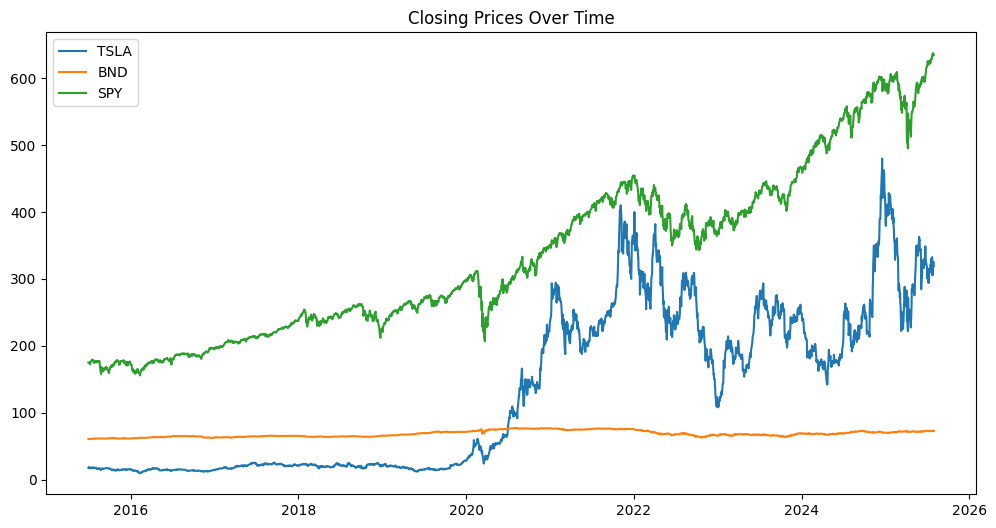

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
for ticker in tickers:
    plt.plot(data[ticker].index, data[ticker]['Close'], label=ticker)
plt.legend()
plt.title("Closing Prices Over Time")
plt.show()


In [7]:
returns = {}
for ticker in tickers:
    returns[ticker] = data[ticker]['Adj Close'].pct_change()
    returns[ticker].name = ticker

returns_df = pd.concat(returns.values(), axis=1)

# Volatility (Rolling Std Dev)
rolling_vol = returns_df.rolling(window=21).std()

returns_df.plot(figsize=(12,6), title="Daily Returns")
rolling_vol.plot(figsize=(12,6), title="Rolling Volatility (21-day)")


KeyError: 'Adj Close'

In [8]:
threshold = 0.05  # 5% daily move
outliers = {}
for ticker in tickers:
    outliers[ticker] = returns_df[abs(returns_df[ticker]) > threshold]


NameError: name 'returns_df' is not defined